# PitchBook on WRDS — EDA Notebook

Canonical notebook for PitchBook data on WRDS. Covers PE deal activity, fund formation, and fund performance.

## Key facts
- `dealsize`, `fundsize`, `aum`, `nav`, all financial columns: **USD millions** — do NOT divide by 1e6
- `dealdate` has outliers (1820–2030): always filter with `BETWEEN '1950-01-01' AND CURRENT_DATE`
- `pitchbk.*` = views; data lives in `pitchbk_companies_deals` and `pitchbk_investors_funds_lps`
- Boolean flags (`isleadinvestor`, `addon`, etc.) are varchar(3) `'Yes'`/`'No'`, not booleans
- CIK crosswalk: use `companycikcoderelation`, not `company.cikcode` (can be semicolon-delimited)
- `wrds_fund_returns` preferred over raw `fundreturnrelation` (more rows, fund name denormalized)

## Contents
1. Connection + schema check
2. PE deal activity (annual Buyout/LBO + Growth counts and size)
3. VC deal activity (rounds by stage)
4. Fund formation (vintage-year counts and capital raised by strategy)
5. Fund performance (IRR/TVPI distribution by vintage)
6. Data quality summary (null rates, date outliers, unit confirmation)

In [1]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

conn = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu',
    port=9737,
    database='wrds',
    user='eddyhu',
    sslmode='require'
)
cur = conn.cursor()
print('Connected to WRDS')

Connected to WRDS


## 1. Schema check: row counts and coverage

In [2]:
checks = [
    ('pitchbk_companies_deals', 'company',
     'COUNT(*), MIN(lastupdated)::text, MAX(lastupdated)::text'),
    ('pitchbk_companies_deals', 'deal',
     'COUNT(*), MIN(dealdate)::text, MAX(dealdate)::text'),
    ('pitchbk_investors_funds_lps', 'fund',
     'COUNT(*), MIN(closedate)::text, MAX(closedate)::text'),
    ('pitchbk_fund_returns', 'wrds_fund_returns',
     'COUNT(*), MIN(asofyear)::text, MAX(asofyear)::text'),
]
rows = []
for schema, table, agg in checks:
    cur.execute(f'SELECT {agg} FROM {schema}.{table}')
    cnt, lo, hi = cur.fetchone()
    rows.append({'table': f'{schema}.{table}', 'rows': cnt, 'min': lo, 'max': hi})

pd.DataFrame(rows).set_index('table')

,rows,min,max
table,,,
pitchbk_companies_deals.company,10281907,2025-09-26,2026-03-25
pitchbk_companies_deals.deal,2971688,1820-01-01,2030-12-31
pitchbk_investors_funds_lps.fund,161277,1959-08-01,2026-03-23
pitchbk_fund_returns.wrds_fund_returns,664095,1982,2026


In [3]:
# Confirm dealsize units: USD millions
# Blackstone's $26B Hilton buyout (2007) should show dealsize ~26000
cur.execute("""
    SELECT companyname, dealdate, dealtype, dealsize, nativecurrencyofdeal
    FROM pitchbk_companies_deals.deal
    WHERE dealsize > 20000
      AND nativecurrencyofdeal = 'US Dollars (USD)'
      AND dealdate BETWEEN '2000-01-01' AND '2026-12-31'
    ORDER BY dealsize DESC
    LIMIT 10
""")
df = pd.DataFrame(cur.fetchall(),
                  columns=['company', 'dealdate', 'dealtype', 'dealsize_mn', 'currency'])
print('Largest USD deals (confirms dealsize is in USD MILLIONS):')
df

Largest USD deals (confirms dealsize is in USD MILLIONS):


,company,dealdate,dealtype,dealsize_mn,currency
0,xAI,2026-02-02,Merger/Acquisition,250000.0,US Dollars (USD)
1,Allergan,2015-10-29,Merger/Acquisition,160000.0,US Dollars (USD)
2,Yahoo,2001-01-11,Merger/Acquisition,147000.0,US Dollars (USD)
3,Unilever,2017-02-17,Merger/Acquisition,143000.0,US Dollars (USD)
4,IHS Markit,2022-02-28,Merger/Acquisition,140000.0,US Dollars (USD)
5,Charter Communications,2017-05-31,Merger/Acquisition,140000.0,US Dollars (USD)
6,Qualcomm,2018-03-16,Merger/Acquisition,117000.0,US Dollars (USD)
7,Warner Bros. Discovery,2026-02-27,Merger/Acquisition,110000.0,US Dollars (USD)
8,Warner-Lambert Company,2000-06-19,Merger/Acquisition,110000.0,US Dollars (USD)
9,OpenAI,2026-02-27,Later Stage VC,110000.0,US Dollars (USD)


## 2. PE deal activity

In [4]:
cur.execute("""
    SELECT
        EXTRACT(YEAR FROM dealdate)::int AS deal_year,
        dealtype,
        COUNT(*)                         AS deal_count,
        SUM(dealsize)                    AS total_size_mn
    FROM pitchbk_companies_deals.deal
    WHERE dealclass = 'Private Equity'
      AND dealstatus = 'Completed'
      AND dealdate BETWEEN %(start)s AND %(end)s
    GROUP BY deal_year, dealtype
    ORDER BY deal_year, deal_count DESC
""", {'start': '2005-01-01', 'end': '2026-12-31'})
pe_df = pd.DataFrame(cur.fetchall(),
                     columns=['year', 'dealtype', 'count', 'total_mn'])
print(f'{pe_df.dealtype.nunique()} PE deal types; top by volume:')
pe_df.groupby('dealtype')['count'].sum().sort_values(ascending=False).head(10)

43 PE deal types; top by volume:


dealtype
Buyout/LBO                             195555
PE Growth/Expansion                     62957
PIPE                                    10153
Secondary Transaction - Private          9661
Platform Creation                        2715
Joint Venture                            2436
Secondary Transaction - Open Market      2078
Dividend Recapitalization                1387
Merger/Acquisition                        799
Investor Buyout by Management             700
Name: count, dtype: int64

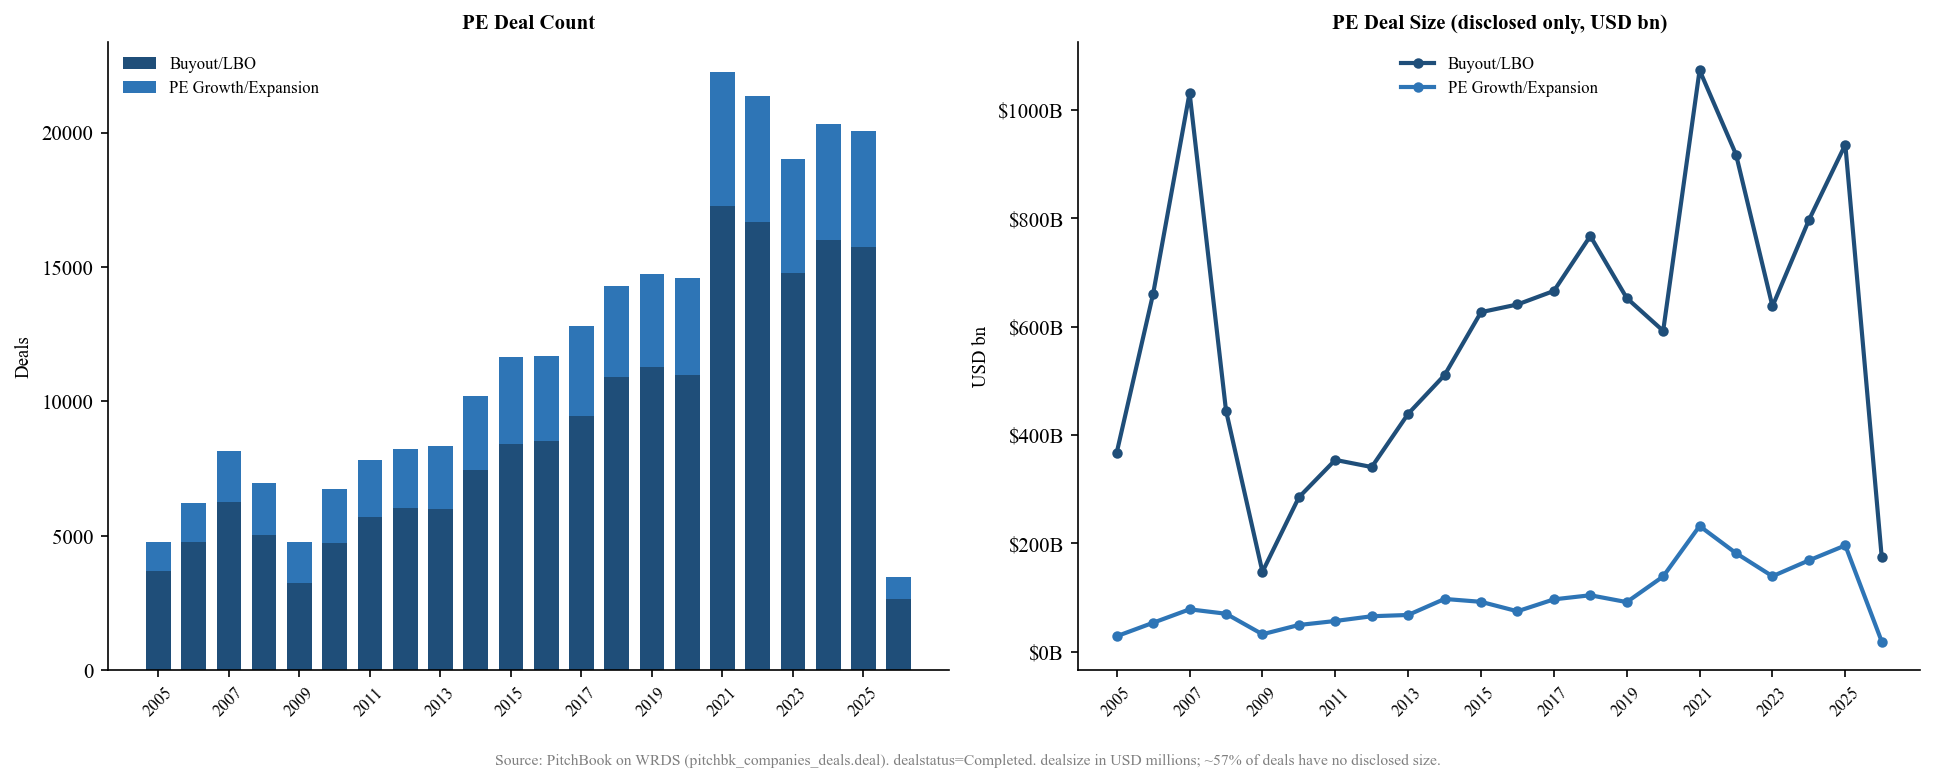

In [5]:
pe_focus = pe_df[pe_df['dealtype'].isin(['Buyout/LBO', 'PE Growth/Expansion'])]
pe_pivot = pe_focus.groupby(['year', 'dealtype'])['count'].sum().unstack(fill_value=0)
pe_size = pe_focus.groupby(['year', 'dealtype'])['total_mn'].sum().unstack(fill_value=0) / 1000
years = [int(y) for y in pe_pivot.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
lbo_vals = [int(pe_pivot.loc[y, 'Buyout/LBO']) if y in pe_pivot.index else 0 for y in years]
gro_vals = [int(pe_pivot.loc[y, 'PE Growth/Expansion']) if y in pe_pivot.index else 0 for y in years]
ax1.bar(years, lbo_vals, color='#1f4e79', label='Buyout/LBO', width=0.7)
ax1.bar(years, gro_vals, bottom=lbo_vals, color='#2e75b6', label='PE Growth/Expansion', width=0.7)
ax1.set_title('PE Deal Count', fontsize=10, fontweight='bold')
ax1.set_ylabel('Deals', fontsize=9)
ax1.legend(fontsize=8, frameon=False)
ax1.set_xticks(years[::2])
ax1.set_xticklabels(years[::2], rotation=45, fontsize=8)

pe_size.index = [int(y) for y in pe_size.index]
for col, color in [('Buyout/LBO', '#1f4e79'), ('PE Growth/Expansion', '#2e75b6')]:
    if col in pe_size.columns:
        ax2.plot(pe_size.index, pe_size[col], color=color, marker='o',
                 linewidth=2, markersize=4, label=col)
ax2.set_title('PE Deal Size (disclosed only, USD bn)', fontsize=10, fontweight='bold')
ax2.set_ylabel('USD bn', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax2.legend(fontsize=8, frameon=False)
ax2.set_xticks(years[::2])
ax2.set_xticklabels(years[::2], rotation=45, fontsize=8)

fig.text(0.5, -0.03,
         'Source: PitchBook on WRDS (pitchbk_companies_deals.deal). '
         'dealstatus=Completed. dealsize in USD millions; ~57% of deals have no disclosed size.',
         ha='center', fontsize=7.5, color='gray')
plt.tight_layout()
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_pe_deal_activity.png', dpi=300, bbox_inches='tight')
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_pe_deal_activity.svg', dpi=300, bbox_inches='tight')
plt.show()

## 3. VC deal activity — North America, rounds by stage

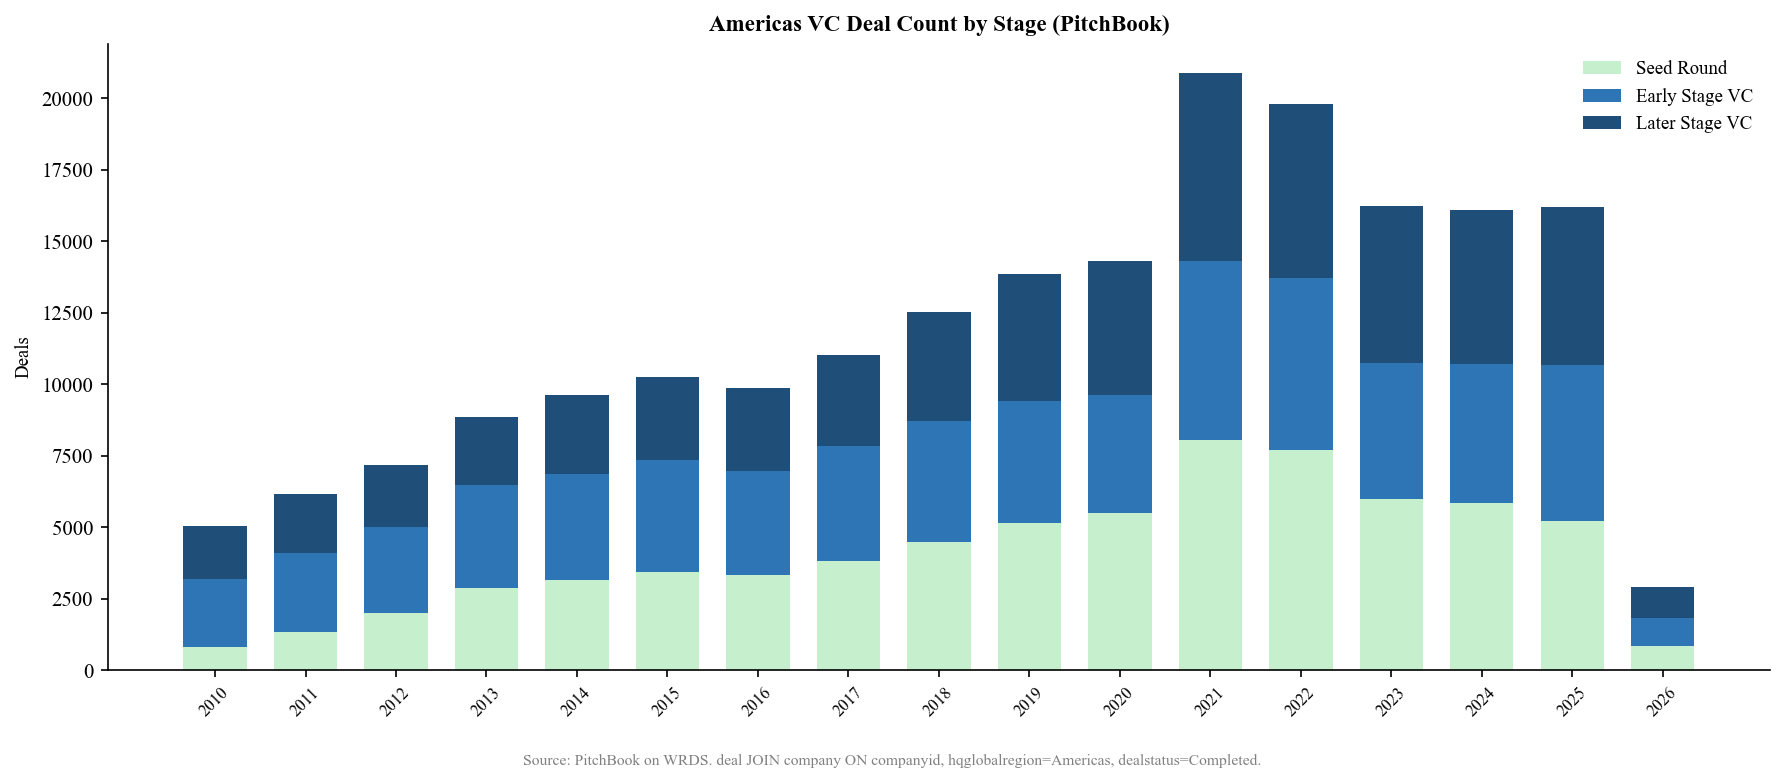

In [6]:
cur.execute("""
    SELECT
        EXTRACT(YEAR FROM d.dealdate)::int AS deal_year,
        d.dealtype,
        COUNT(*) AS deal_count
    FROM pitchbk_companies_deals.deal d
    JOIN pitchbk_companies_deals.company c ON d.companyid = c.companyid
    WHERE d.dealclass = 'Venture Capital'
      AND d.dealstatus = 'Completed'
      AND c.hqglobalregion = 'Americas'
      AND d.dealdate BETWEEN %(start)s AND %(end)s
    GROUP BY deal_year, d.dealtype
    ORDER BY deal_year, deal_count DESC
""", {'start': '2010-01-01', 'end': '2026-12-31'})
vc_df = pd.DataFrame(cur.fetchall(), columns=['year', 'dealtype', 'count'])
vc_df['year'] = vc_df['year'].astype(int)

vc_types = ['Seed Round', 'Early Stage VC', 'Later Stage VC']
vc_focus = vc_df[vc_df['dealtype'].isin(vc_types)]
vc_pivot = vc_focus.groupby(['year', 'dealtype'])['count'].sum().unstack(fill_value=0)
vc_years = [int(y) for y in vc_pivot.index]

COLORS_VC = {'Seed Round': '#c6efce', 'Early Stage VC': '#2e75b6', 'Later Stage VC': '#1f4e79'}
fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(vc_pivot))
for col in vc_types:
    if col in vc_pivot.columns:
        ax.bar(vc_years, vc_pivot[col].values, bottom=bottom,
               color=COLORS_VC[col], label=col, width=0.7)
        bottom = bottom + vc_pivot[col].values.astype(float)
ax.set_title('Americas VC Deal Count by Stage (PitchBook)', fontsize=11, fontweight='bold')
ax.set_ylabel('Deals', fontsize=9)
ax.legend(fontsize=9, frameon=False)
ax.set_xticks(vc_years)
ax.set_xticklabels(vc_years, rotation=45, fontsize=8)
fig.text(0.5, -0.03,
         'Source: PitchBook on WRDS. deal JOIN company ON companyid, hqglobalregion=Americas, dealstatus=Completed.',
         ha='center', fontsize=7.5, color='gray')
plt.tight_layout()
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_vc_rounds_na.png', dpi=300, bbox_inches='tight')
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_vc_rounds_na.svg', dpi=300, bbox_inches='tight')
plt.show()

## 4. Fund formation — vintage-year counts and capital raised

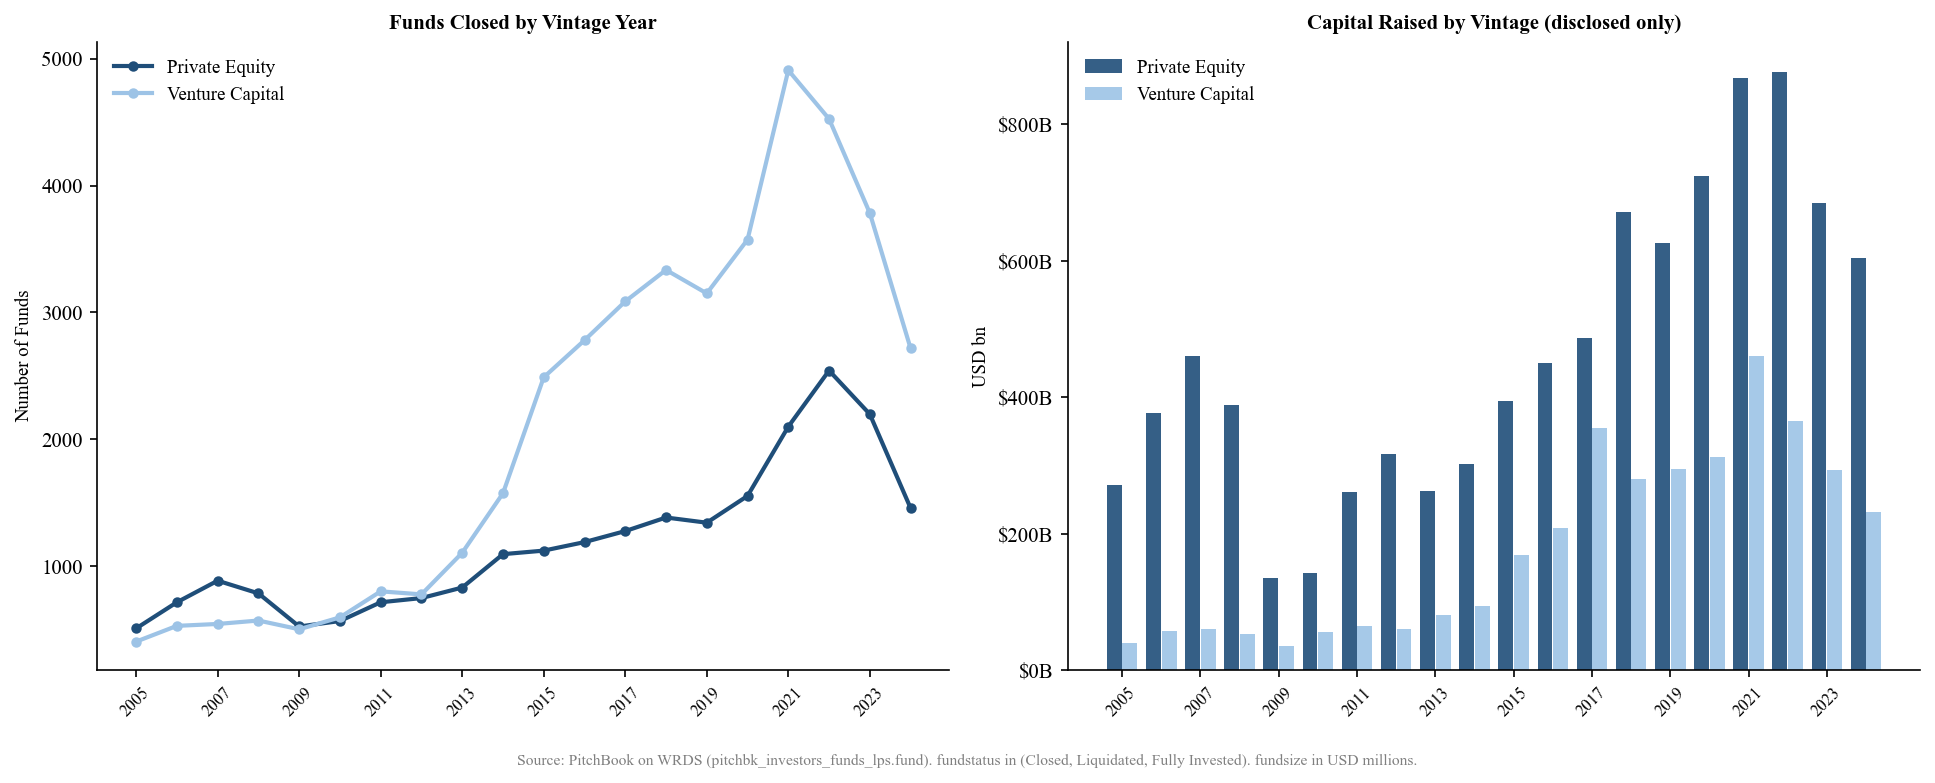

% of closed funds with disclosed size by category:
category
Private Equity     78.5
Venture Capital    83.4


In [7]:
cur.execute("""
    SELECT
        vintage::int                             AS vintage_year,
        fundcategory,
        COUNT(*)                                 AS funds_closed,
        SUM(fundsize)                            AS total_raised_mn,
        COUNT(*) FILTER (WHERE fundsize IS NOT NULL) AS funds_with_size
    FROM pitchbk_investors_funds_lps.fund
    WHERE fundstatus IN ('Closed', 'Liquidated', 'Fully Invested')
      AND fundcategory IN ('Venture Capital', 'Private Equity')
      AND vintage BETWEEN %(start)s AND %(end)s
    GROUP BY vintage_year, fundcategory
    ORDER BY vintage_year, fundcategory
""", {'start': 2005, 'end': 2024})
fund_df = pd.DataFrame(cur.fetchall(),
                       columns=['vintage', 'category', 'funds', 'total_mn', 'funds_with_size'])
fund_df['vintage'] = fund_df['vintage'].astype(int)
fund_df['pct_disclosed'] = (fund_df['funds_with_size'] / fund_df['funds'] * 100).round(1)
vintages = sorted(fund_df['vintage'].unique().tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for cat, color in [('Private Equity', '#1f4e79'), ('Venture Capital', '#9dc3e6')]:
    sub = fund_df[fund_df['category'] == cat].set_index('vintage')
    sub.index = sub.index.astype(int)
    ax1.plot(sub.index, sub['funds'], color=color, marker='o',
             linewidth=2, markersize=4, label=cat)
    offset = -0.2 if cat == 'Private Equity' else 0.2
    ax2.bar(sub.index + offset, sub['total_mn'].fillna(0) / 1000,
            width=0.38, color=color, label=cat, alpha=0.9)

ax1.set_title('Funds Closed by Vintage Year', fontsize=10, fontweight='bold')
ax1.set_ylabel('Number of Funds', fontsize=9)
ax1.legend(fontsize=9, frameon=False)
ax1.set_xticks(vintages[::2])
ax1.set_xticklabels(vintages[::2], rotation=45, fontsize=8)

ax2.set_title('Capital Raised by Vintage (disclosed only)', fontsize=10, fontweight='bold')
ax2.set_ylabel('USD bn', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax2.legend(fontsize=9, frameon=False)
ax2.set_xticks(vintages[::2])
ax2.set_xticklabels(vintages[::2], rotation=45, fontsize=8)

fig.text(0.5, -0.03,
         'Source: PitchBook on WRDS (pitchbk_investors_funds_lps.fund). '
         'fundstatus in (Closed, Liquidated, Fully Invested). fundsize in USD millions.',
         ha='center', fontsize=7.5, color='gray')
plt.tight_layout()
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_fund_formation.png', dpi=300, bbox_inches='tight')
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_fund_formation.svg', dpi=300, bbox_inches='tight')
plt.show()

print('% of closed funds with disclosed size by category:')
print(fund_df.groupby('category')['pct_disclosed'].mean().round(1).to_string())

## 5. Fund performance — IRR and TVPI by vintage

Using `wrds_fund_returns` (preferred over raw `fundreturnrelation`). Latest annual (4Q) observation per fund.

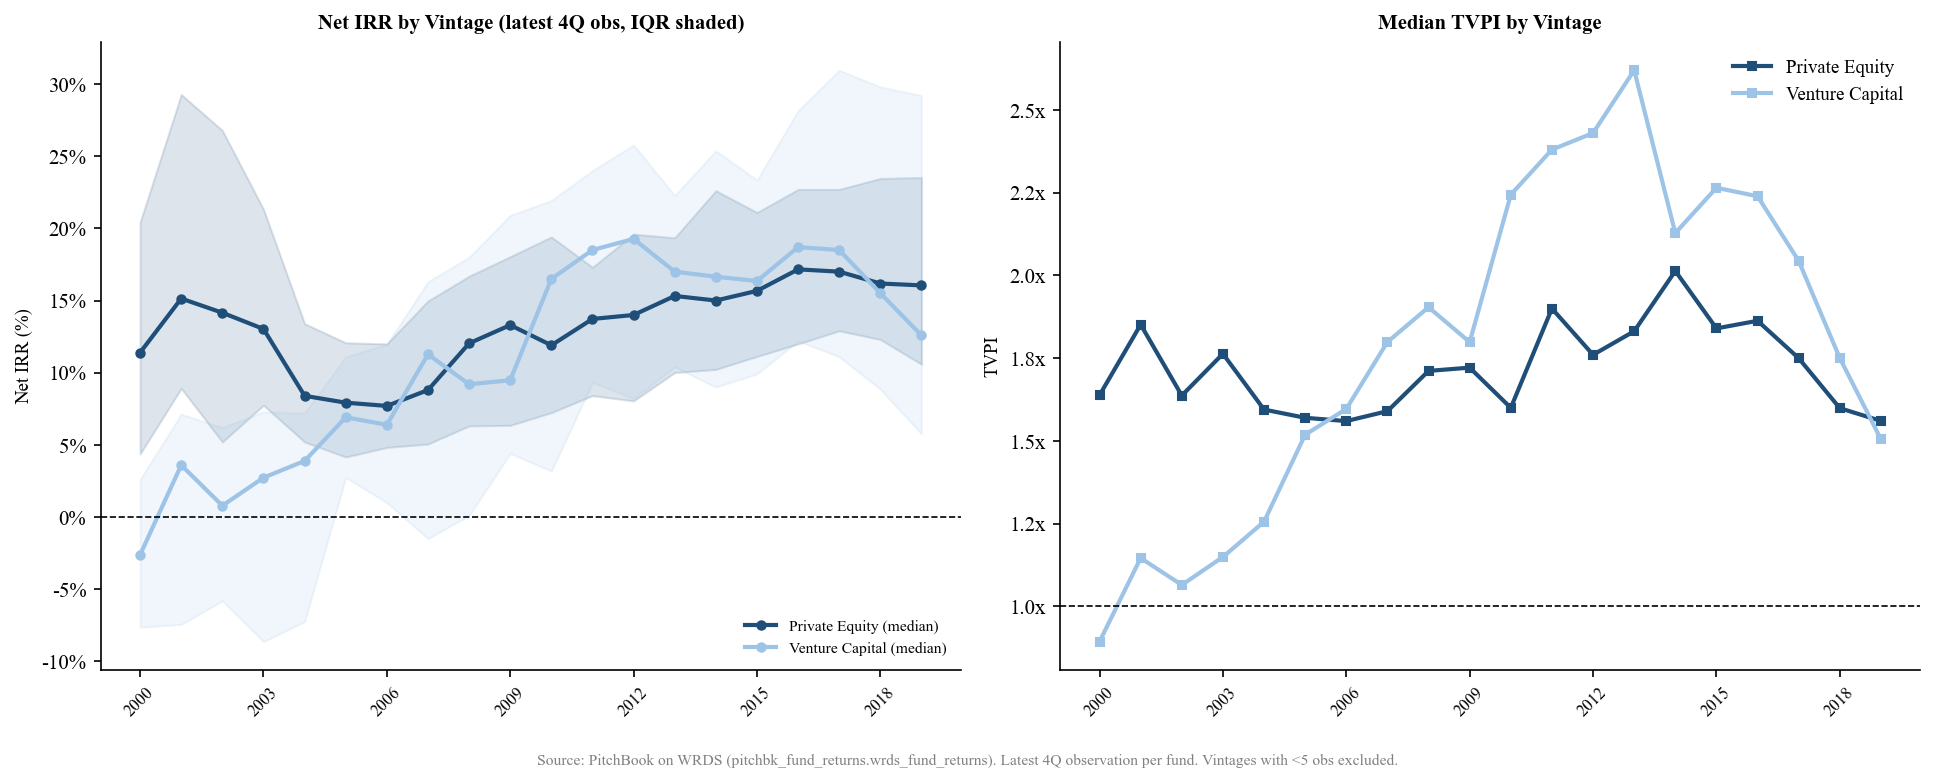

In [8]:
cur.execute("""
    WITH latest AS (
        SELECT fundid, MAX(asofyear) AS max_year
        FROM pitchbk_fund_returns.wrds_fund_returns
        WHERE asofquarter = '4Q'
        GROUP BY fundid
    )
    SELECT
        f.vintage::int AS vintage_year,
        f.fundcategory,
        COUNT(*) AS obs,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY r.irr)  AS irr_p25,
        PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY r.irr)  AS irr_median,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY r.irr)  AS irr_p75,
        PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY r.tvpi) AS tvpi_median
    FROM pitchbk_investors_funds_lps.fund f
    JOIN pitchbk_fund_returns.wrds_fund_returns r ON f.fundid = r.fundid
    JOIN latest l ON r.fundid = l.fundid AND r.asofyear = l.max_year
    WHERE r.asofquarter = '4Q'
      AND f.fundcategory IN ('Venture Capital', 'Private Equity')
      AND f.vintage BETWEEN 2000 AND 2019
      AND r.irr IS NOT NULL
    GROUP BY vintage_year, f.fundcategory
    HAVING COUNT(*) >= 5
    ORDER BY vintage_year, f.fundcategory
""")
perf_df = pd.DataFrame(cur.fetchall(),
                       columns=['vintage', 'category', 'obs',
                                'irr_p25', 'irr_median', 'irr_p75', 'tvpi_median'])
perf_df['vintage'] = perf_df['vintage'].astype(int)
vintages = sorted(perf_df['vintage'].unique().tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for cat, color in [('Private Equity', '#1f4e79'), ('Venture Capital', '#9dc3e6')]:
    sub = perf_df[perf_df['category'] == cat].set_index('vintage')
    sub.index = sub.index.astype(int)
    ax1.plot(sub.index, sub['irr_median'], color=color, marker='o',
             linewidth=2, markersize=4, label=f'{cat} (median)')
    ax1.fill_between(sub.index, sub['irr_p25'], sub['irr_p75'],
                     color=color, alpha=0.15)
    ax2.plot(sub.index, sub['tvpi_median'], color=color, marker='s',
             linewidth=2, markersize=4, label=cat)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Net IRR by Vintage (latest 4Q obs, IQR shaded)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Net IRR (%)', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax1.legend(fontsize=7.5, frameon=False)
ax1.set_xticks(vintages[::3])
ax1.set_xticklabels(vintages[::3], rotation=45, fontsize=8)

ax2.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Median TVPI by Vintage', fontsize=10, fontweight='bold')
ax2.set_ylabel('TVPI', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax2.legend(fontsize=9, frameon=False)
ax2.set_xticks(vintages[::3])
ax2.set_xticklabels(vintages[::3], rotation=45, fontsize=8)

fig.text(0.5, -0.03,
         'Source: PitchBook on WRDS (pitchbk_fund_returns.wrds_fund_returns). '
         'Latest 4Q observation per fund. Vintages with <5 obs excluded.',
         ha='center', fontsize=7.5, color='gray')
plt.tight_layout()
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_fund_performance.png', dpi=300, bbox_inches='tight')
fig.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/pb_fund_performance.svg', dpi=300, bbox_inches='tight')
plt.show()

## 6. Data quality summary

In [9]:
cur.execute("""
    SELECT
        COUNT(*) AS total_completed,
        ROUND(100.0 * COUNT(*) FILTER (WHERE dealsize IS NULL) / COUNT(*), 1)
            AS pct_null_dealsize,
        ROUND(100.0 * COUNT(*) FILTER (WHERE premoneyvaluation IS NULL) / COUNT(*), 1)
            AS pct_null_premoney,
        ROUND(100.0 * COUNT(*) FILTER (WHERE postvaluation IS NULL) / COUNT(*), 1)
            AS pct_null_postval,
        COUNT(*) FILTER (WHERE dealdate < '1950-01-01') AS deals_pre_1950,
        COUNT(*) FILTER (WHERE dealdate > CURRENT_DATE) AS deals_future
    FROM pitchbk_companies_deals.deal
    WHERE dealstatus = 'Completed'
""")
row = cur.fetchone()
labels = ['total_completed', 'null_dealsize_%', 'null_premoney_%',
          'null_postval_%', 'deals_pre_1950', 'deals_future']
print('Completed deals — data quality:')
for l, v in zip(labels, row):
    print(f'  {l:22s}: {v:>12,}')
print("\nAlways filter: dealdate BETWEEN '1950-01-01' AND CURRENT_DATE")

Completed deals — data quality:
  total_completed       :    2,904,925
  null_dealsize_%       :         56.6
  null_premoney_%       :         90.5
  null_postval_%        :         82.1
  deals_pre_1950        :        1,111
  deals_future          :            0

Always filter: dealdate BETWEEN '1950-01-01' AND CURRENT_DATE


In [10]:
cur.execute("""
    SELECT dealclass, COUNT(*) AS cnt
    FROM pitchbk_companies_deals.deal
    WHERE dealdate BETWEEN '1990-01-01' AND CURRENT_DATE
    GROUP BY dealclass ORDER BY cnt DESC
""")
dc = pd.DataFrame(cur.fetchall(), columns=['dealclass', 'count'])
dc['pct'] = (dc['count'] / dc['count'].sum() * 100).round(1)
print('dealclass distribution (post-1990, all statuses):')
print(dc.to_string(index=False))

conn.close()
print('\nDone.')

dealclass distribution (post-1990, all statuses):
        dealclass  count  pct
        Corporate 730663 27.3
  Venture Capital 569292 21.3
            Other 372794 13.9
   Private Equity 321202 12.0
             Debt 307616 11.5
       Individual 123687  4.6
  Out of Business 102903  3.8
Public Investment  87482  3.3
       Bankruptcy  32169  1.2
             None  28879  1.1
       Hedge Fund    506  0.0

Done.
